● Fetch country-wise COVID data
● Analyze recovery and death rates
● Compare countries
● Create charts and heatmaps
● Generate daily reports
● Track historical trends


First 10 Countries

               country     cases  todayCases  deaths  todayDeaths  recovered  \
0          Afghanistan    234174           0    7996            0     211080   
1              Albania    334863           0    3605            0     330233   
2              Algeria    272010           0    6881            0     183061   
3              Andorra     48015           0     165            0          0   
4               Angola    107327           0    1937            0     103419   
5             Anguilla      3904           0      12            0          0   
6  Antigua and Barbuda      9106           0     146            0       8954   
7            Argentina  10128845           0  130841            0    9997258   
8              Armenia    451831           0    8777            0     435162   
9                Aruba     44224           0     292            0      42438   

   active     tests  population  Recovery Rate (%)  Death Rate (%)  
0   15098   1390730    407543

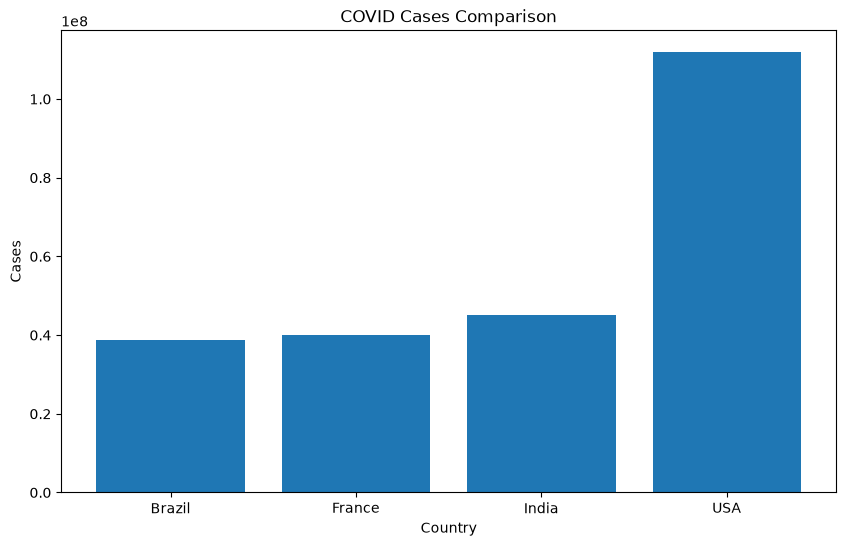

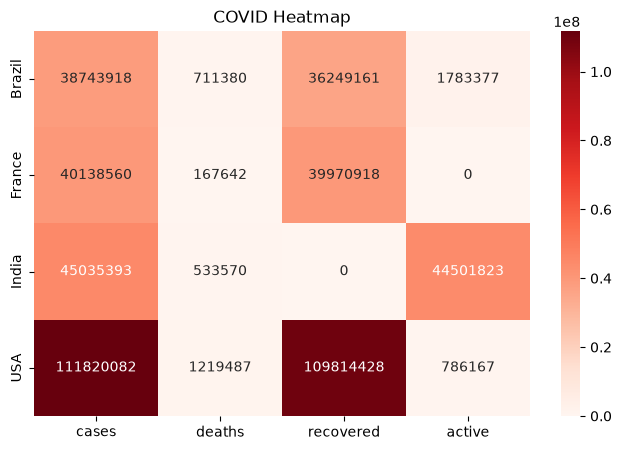


Report Saved Successfully!


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests 
import seaborn as sns

url = "https://disease.sh/v3/covid-19/countries"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)

# Select useful columns
covid = df[[
    'country',
    'cases',
    'todayCases',
    'deaths',
    'todayDeaths',
    'recovered',
    'active',
    'tests',
    'population'
]]

# --------------------------------
# Calculate Recovery & Death Rates
# --------------------------------

covid['Recovery Rate (%)'] = (covid['recovered'] / covid['cases']) * 100
covid['Death Rate (%)'] = (covid['deaths'] / covid['cases']) * 100

print("\nFirst 10 Countries\n")
print(covid.head(10))

# -----------------------
# Top 10 Highest Cases
# -----------------------

top_cases = covid.sort_values(by='cases', ascending=False).head(10)

print("\nTop 10 Countries by Cases\n")
print(top_cases[['country', 'cases']])

# -----------------------
# Compare Countries
# -----------------------

countries = ['India', 'USA', 'Brazil', 'France']

compare = covid[covid['country'].isin(countries)]

print("\nComparison\n")
print(compare[['country', 'cases', 'deaths', 'recovered']])

# -----------------------
# Bar Chart
# -----------------------

plt.figure(figsize=(10,6))

plt.bar(compare['country'], compare['cases'])

plt.title("COVID Cases Comparison")
plt.xlabel("Country")
plt.ylabel("Cases")

plt.show()

# -----------------------
# Heatmap
# -----------------------

heat = compare[['cases','deaths','recovered','active']]

plt.figure(figsize=(8,5))

sns.heatmap(
    heat,
    annot=True,
    cmap="Reds",
    fmt=".0f",
    yticklabels=compare['country']
)

plt.title("COVID Heatmap")

plt.show()

# -----------------------
# Export Daily Report
# -----------------------

covid.to_csv("covid_daily_report.csv", index=False)

print("\nReport Saved Successfully!")

In [3]:
# df=pd.DataFrame(data)
# print(df.to_string())

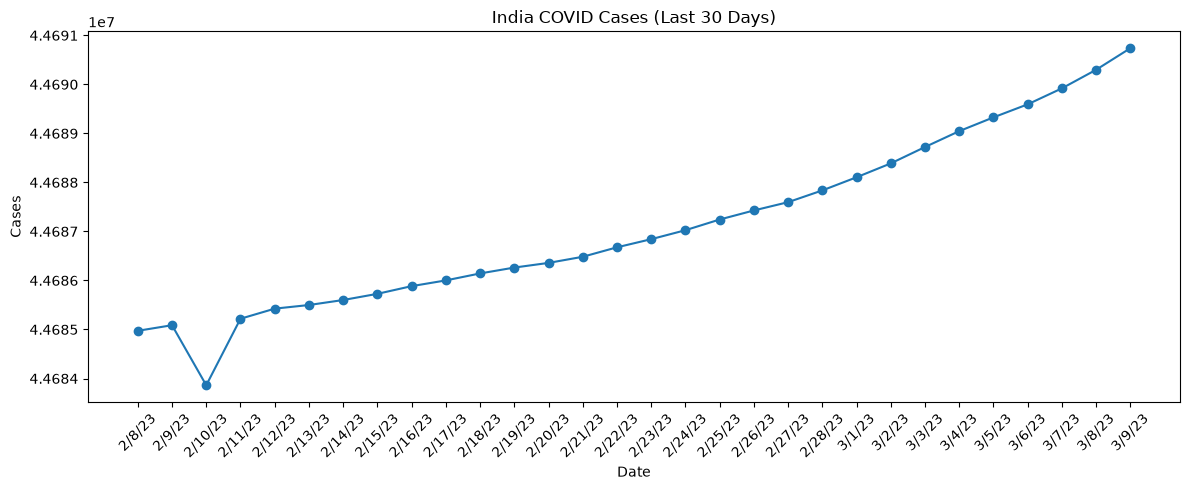

In [4]:
import requests
import matplotlib.pyplot as plt

country = "India"

url = f"https://disease.sh/v3/covid-19/historical/{country}?lastdays=30"

data = requests.get(url).json()

cases = data["timeline"]["cases"]

dates = list(cases.keys())
values = list(cases.values())

plt.figure(figsize=(12,5))

plt.plot(dates, values, marker='o')

plt.xticks(rotation=45)

plt.title(f"{country} COVID Cases (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.tight_layout()
plt.show()